In [1]:
# CELL 1: THE FOUNDATION (Imports & Data Ingestion)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import warnings

# Keep the notebook clean for the portfolio
warnings.filterwarnings('ignore')

print("1. Ingesting Customer Data...")
# Load the CSV (Make sure 'customer_churn.csv' is in the same folder as this notebook)
df = pd.read_csv('customer_churn.csv')

print(f"✅ Dataset loaded successfully: {df.shape[0]} customers, {df.shape[1]} features.")

# Define our core business variables right at the top
target_col = 'churn_flag'
revenue_col = 'total_spent'
id_col = 'customer_id'

print("-" * 40)
print("2. Data Sanity Check (Target & Revenue Columns):")
display(df[[id_col, revenue_col, 'churn_risk', target_col]].head(3))

1. Ingesting Customer Data...
✅ Dataset loaded successfully: 100000 customers, 18 features.
----------------------------------------
2. Data Sanity Check (Target & Revenue Columns):


,customer_id,total_spent,churn_risk,churn_flag
0,C000001,2108.80,Medium,1
1,C000002,3843.06,Medium,1
2,C000003,224.65,High,1


In [2]:
# CELL 2: The Predictive Engine & Business Logic
print("3. Preparing Features and Target...")

# CRITICAL INTERVIEW POINT: We drop 'churn_risk' to prevent Target Leakage.
# We want the model to learn from customer behavior, not from pre-assigned labels.
X = df.drop(columns=[target_col, id_col, 'churn_risk'])
y = df[target_col]

print("4. Encoding and Splitting Data...")
# Convert text features (like 'customer_segment') into numerical 1s and 0s
X_encoded = pd.get_dummies(X, drop_first=True)

# Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("5. Training Random Forest Model (This may take a few seconds)...")
# 'class_weight=balanced' forces the algorithm to penalize missing churners
# 'n_jobs=-1' uses all your CPU cores to train faster
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)

print("6. Calculating Revenue at Risk...")
# Get the probability of churn (0.0 to 1.0)
churn_probs = model.predict_proba(X_test)[:, 1]

# Evaluate the model
roc_auc = roc_auc_score(y_test, churn_probs)
print(f"✅ Model ROC-AUC Score: {roc_auc:.3f}")

# Map predictions back to the test dataset to calculate financial impact
results = df.loc[X_test.index, [id_col, revenue_col, 'customer_segment']].copy()
results['Churn_Probability'] = churn_probs.round(3)
results['Revenue_At_Risk'] = (results[revenue_col] * results['Churn_Probability']).round(2)

# Create the actionable business queue
retention_queue = results.sort_values(by='Revenue_At_Risk', ascending=False)

print("-" * 40)
print("🚨 TOP 5 HIGH-PRIORITY RETENTION TARGETS 🚨")
display(retention_queue.head())

3. Preparing Features and Target...
4. Encoding and Splitting Data...
5. Training Random Forest Model (This may take a few seconds)...
6. Calculating Revenue at Risk...
✅ Model ROC-AUC Score: 0.989
----------------------------------------
🚨 TOP 5 HIGH-PRIORITY RETENTION TARGETS 🚨


,customer_id,total_spent,customer_segment,Churn_Probability,Revenue_At_Risk
71010,C071011,24945.95,New,1.00,24945.95
4168,C004169,25842.33,VIP,0.95,24550.21
11972,C011973,26694.44,VIP,0.90,24025.00
49802,C049803,24616.74,VIP,0.95,23385.90
26115,C026116,25891.24,VIP,0.90,23302.12


7. Generating SHAP Explainer (This takes a few seconds)...
8. Saving High-Resolution SHAP Plot...


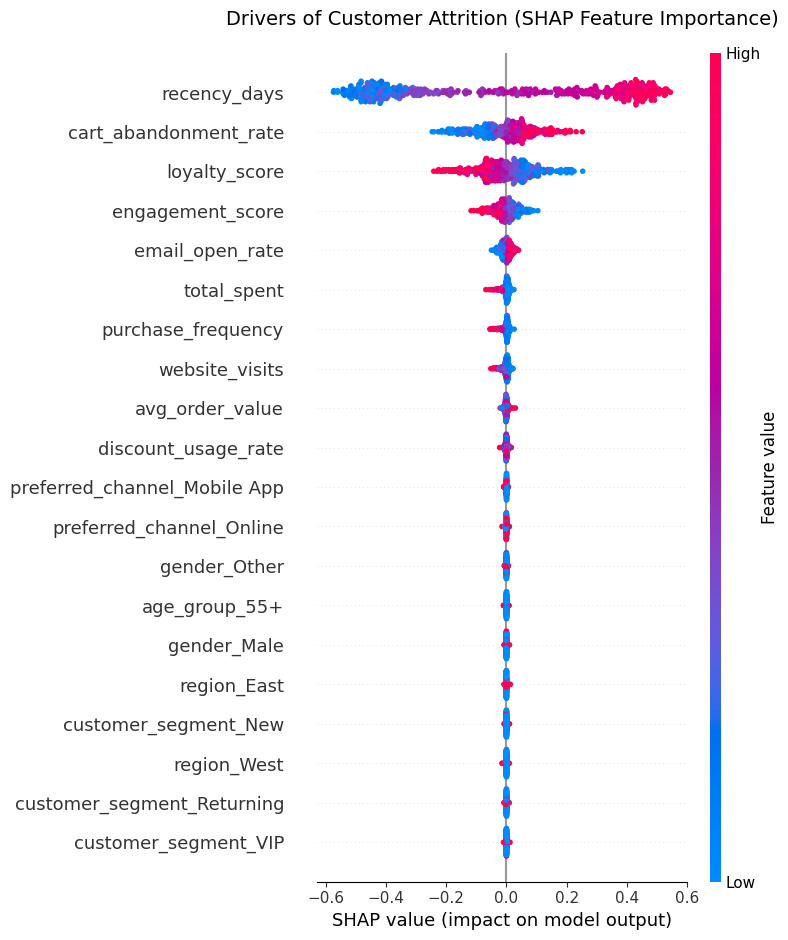

9. Exporting Data for Power BI / Tableau...
----------------------------------------
✅ ARCHITECTURE COMPLETE! Check your project folder for:
🖼️ shap_summary_plot.png (For your Portfolio / LinkedIn)
📊 bi_feature_importance.csv (For Power BI)
📊 bi_retention_queue.csv (For Power BI)


In [3]:
# CELL 3: Explainable AI (SHAP) & Dashboard Export
print("7. Generating SHAP Explainer (This takes a few seconds)...")

# Sample the test data (500 rows is plenty to find the pattern without freezing Zorin OS)
X_test_sample = X_test.sample(n=500, random_state=42)

# Initialize the Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

# Handle SHAP array structures (Different SHAP versions output different shapes)
if isinstance(shap_values, list):
    churn_shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    churn_shap_values = shap_values[:, :, 1]
else:
    churn_shap_values = shap_values

print("8. Saving High-Resolution SHAP Plot...")
# Generate and save the visualization
plt.figure(figsize=(10, 6))
shap.summary_plot(churn_shap_values, X_test_sample, show=False)
plt.title("Drivers of Customer Attrition (SHAP Feature Importance)", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("9. Exporting Data for Power BI / Tableau...")
# Calculate average impact score for the dashboard bar chart
feature_importance = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Impact_Score': np.abs(churn_shap_values).mean(axis=0)
}).sort_values(by='Impact_Score', ascending=False)

# Export the clean CSVs
feature_importance.to_csv('bi_feature_importance.csv', index=False)
retention_queue.to_csv('bi_retention_queue.csv', index=False)

print("-" * 40)
print("✅ ARCHITECTURE COMPLETE! Check your project folder for:")
print("🖼️ shap_summary_plot.png (For your Portfolio / LinkedIn)")
print("📊 bi_feature_importance.csv (For Power BI)")
print("📊 bi_retention_queue.csv (For Power BI)")